In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
data=pd.read_csv("Social_Network_Ads.csv")

In [3]:
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
x=data.iloc[:,[2,3]].values
y=data.iloc[:,4].values   # arr


In [8]:
from sklearn.model_selection import train_test_split

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42,stratify=y)

In [12]:
mean=x_train.mean()
std=x_train.std()
x_train - mean /std

array([[2.31779338e+01, 5.79991779e+04],
       [3.01779338e+01, 3.39991779e+04],
       [3.71779338e+01, 7.99991779e+04],
       [5.71779338e+01, 2.29991779e+04],
       [4.01779338e+01, 5.99991779e+04],
       [3.81779338e+01, 7.69991779e+04],
       [5.91779338e+01, 8.29991779e+04],
       [4.11779338e+01, 5.39991779e+04],
       [3.61779338e+01, 7.79991779e+04],
       [3.61779338e+01, 7.69991779e+04],
       [2.71779338e+01, 5.89991779e+04],
       [1.91779338e+01, 2.29991779e+04],
       [2.31779338e+01, 8.89991779e+04],
       [2.71779338e+01, 4.39991779e+04],
       [4.51779338e+01, 4.09991779e+04],
       [4.71779338e+01, 2.89991779e+04],
       [3.81779338e+01, 1.05999178e+05],
       [3.11779338e+01, 1.19999178e+05],
       [3.31779338e+01, 1.11999178e+05],
       [3.81779338e+01, 7.09991779e+04],
       [4.81779338e+01, 3.89991779e+04],
       [3.11779338e+01, 1.79991779e+04],
       [1.71779338e+01, 4.39991779e+04],
       [3.71779338e+01, 1.12999178e+05],
       [3.617793

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
sc_x=StandardScaler()
x_train=sc_x.fit_transform(x_train)
x_test=sc_x.transform(x_test)

In [23]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression()
classifier.fit(x_train,y_train)
y_pred_test=classifier.predict(x_test)
y_pred_train=classifier.predict(x_train)

In [24]:
from sklearn.metrics import confusion_matrix , accuracy_score , recall_score , precision_score , f1_score

In [25]:
print("cm",confusion_matrix(y_test,y_pred_test))
print("acc",accuracy_score(y_test,y_pred_test))
print("re",recall_score(y_test,y_pred_test))
print("p",precision_score(y_test,y_pred_test))
print("f1 test",f1_score(y_test,y_pred_test))
print("f1 train",f1_score(y_train,y_pred_train))

cm [[48  3]
 [10 19]]
acc 0.8375
re 0.6551724137931034
p 0.8636363636363636
f1 test 0.7450980392156863
f1 train 0.7677725118483413


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23268\4115875412.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],


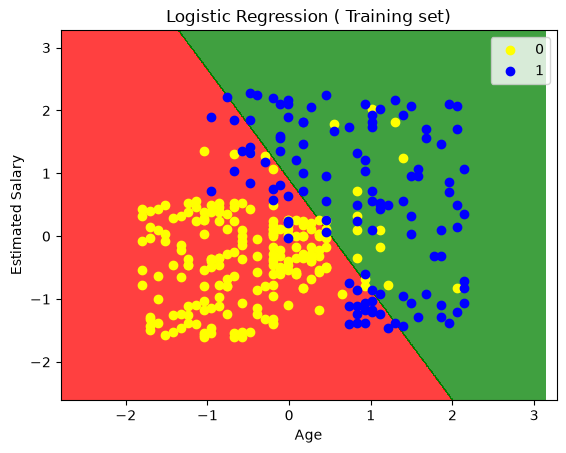

In [26]:


 
# Visualising the Training set results
 
from matplotlib.colors import ListedColormap
X_Set, Y_Set = x_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_Set[:,0].min() -1, stop = X_Set[:, 0].max() +1, step = 0.01),
                     np.arange(start = X_Set[:,1].min() -1, stop = X_Set[:, 1].max() +1, step = 0.01))
 
 
plt.contourf(X1,X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
 
plt.xlim(X1.min(), X2.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(Y_Set)):
    plt.scatter(X_Set[Y_Set == j, 0], X_Set[Y_Set == j,1],
                c = ListedColormap(('yellow', 'blue'))(i), label = j)
plt.title('Logistic Regression ( Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()
 
 